In [29]:
%pip install pillow numpy onnxruntime

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import io
import numpy as np
from PIL import Image
import onnxruntime as ort

# 모델 불러오기

In [2]:
sess = ort.InferenceSession('result.onnx')
sess

# 이미지를 바이트로 변환

In [ ]:
with open("test.jpg", "rb") as f:
    img=f.read()

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\t\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x02\x80\x02\x80\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\xc9\xca\xd2\xd3\

# 모델의 이미지 사이즈 가져오기(배치, 채널, 높이, 너비)

In [7]:
SIZE=sess.get_inputs()[0].shape[2:]
SIZE

[224, 224]

# 바이트를 이미지 분석용으로 가져오기

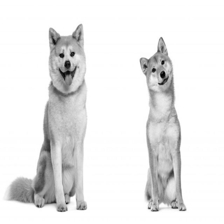

In [8]:
img = Image.open(io.BytesIO(img)).convert('RGB').resize(SIZE)
img

# 0~1로 정규화 하기

In [9]:
img_np = np.array(img, dtype=np.float32) / 255.0

# 정규화 하기

In [10]:
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
chw_img = np.transpose((img_np - mean) / std, (2, 0, 1))
x = np.expand_dims(chw_img, axis=0)

# 결과 예측

In [11]:
classes = ['Lie', 'Seat', 'Stay']

input_name = sess.get_inputs()[0].name
outputs = sess.run(None, {input_name: x})
pred = classes[outputs[0].argmax()]
pred

'Seat'